# Decente de gradient en 2D et lien avec l'intelligence artificielle

## Objectif

Ce projet vise à étudier l'optimisation d'une fonction à deux variables à l'aide des dérivées partielles et de la decente de gradient.

Objectifs spécifiques:

- calculer les dérivées partielles
- construire le vecteur gradient
- appliquer la decente de gradient
- visualiser le processus d'optimisation
- établir un lien avec les systèmes d'IA

## Définition de la fonction

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


In [57]:
x_s,y_s = sp.symbols('x y')
f_expr = x_s**2 + y_s**2

df_dx = sp.diff(f_expr,x_s)
df_dy = sp.diff(f_expr,y_s)

f_expr, df_dx, df_dy

(x**2 + y**2, 2*x, 2*y)

In [62]:
lamdadify = True
if lamdadify:
    f = sp.lambdify((x_s,y_s), f_expr, 'numpy')
    grad_f = sp.lambdify((x_s,y_s), [df_dx, df_dy], 'numpy')
else:
    def f(x,y):
        return x**2 + y**2

    def grad_f(x,y):
        df_dx = 2*x
        df_dy = 2*y
        return np.array([df_dx, df_dy])

def gradient_descent(start, alpha = 0.2, steps = 20):
    """
    alpha: learning rate
    steps: number of iterations
    start: initial point (tuple or list of two elements)
    """
    point = np.array(start, dtype=float)
    path = [point.copy()]

    for _ in range(steps):
        point = point - alpha * np.array(grad_f(point[0], point[1]), dtype=float)
        path.append(point.copy())

    return np.array(path)

path = gradient_descent(start=(-2, 3), alpha=0.1, steps=50)

x_vals = np.linspace(-4, 4, 200)
y_vals = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x_vals, y_vals)
Z = f(X, Y)


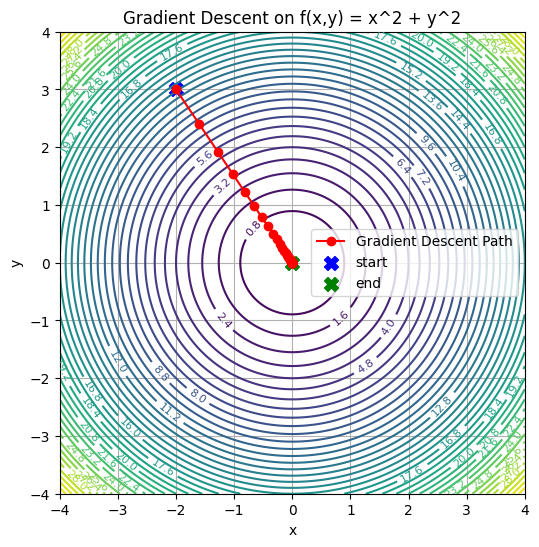

In [63]:
plt.figure(figsize=(6, 6))
#contour plot
contour = plt.contour(X,Y,Z, levels=50, cmap='viridis')
plt.clabel(contour, inline=1, fontsize=8)

#path
plt.plot(path[:,0], path[:,1], marker='o', color='red', label ='Gradient Descent Path')

plt.scatter(path[0,0], path[0,1], color='blue', marker='X', s=100, label='start')
plt.scatter(path[-1,0], path[-1,1], color='green', marker='X', s=100, label='end')
plt.title('Gradient Descent on f(x,y) = x^2 + y^2')
plt.xlabel('x')     
plt.ylabel('y')
plt.legend()
plt.grid()  
plt.show()  

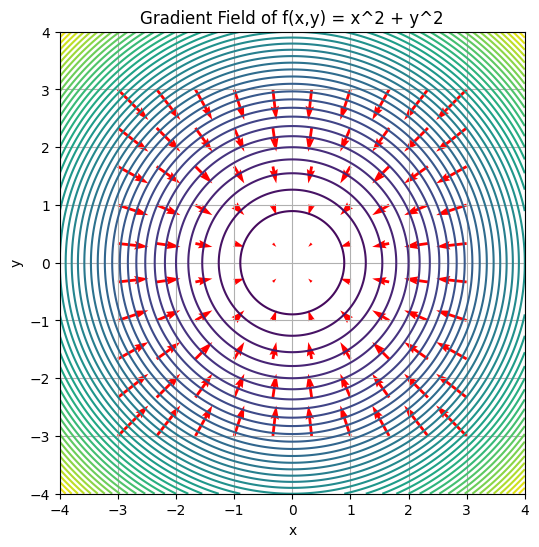

In [64]:
plt.figure(figsize=(6, 6))

plt.contour(X,Y,Z, levels=50, cmap='viridis')

sample_x = np.linspace(-3, 3,10)
sample_y = np.linspace(-3, 3,10)
SX,SY = np.meshgrid(sample_x, sample_y)

U = 2*SX
V = 2*SY

plt.quiver(SX, SY, -U, -V, color='red')
plt.title('Gradient Field of f(x,y) = x^2 + y^2')
plt.xlabel('x') 
plt.ylabel('y')
plt.grid()  
plt.show()

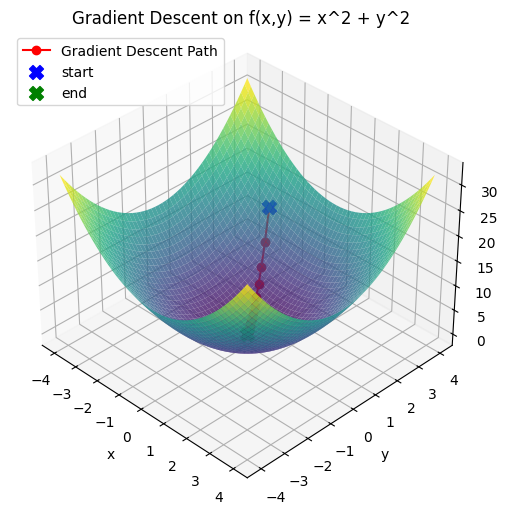

In [65]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=35, azim=-45)
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
ax.plot(path[:,0], path[:,1], f(path[:,0], path[:,1]), marker='o', color='red', label ='Gradient Descent Path')
ax.scatter(path[0,0], path[0,1], f(path[0,0], path[0,1]), color='blue', marker='X', s=100, label='start')
ax.scatter(path[-1,0], path[-1,1], f(path[-1,0], path[-1,1]), color='green', marker='X', s=100, label='end')
ax.set_title('Gradient Descent on f(x,y) = x^2 + y^2')
ax.set_xlabel('x')      
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')
ax.legend()
plt.show()  